In [6]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
colors = ['#cb17eb','#A4EB17', '#17EBC8', '#EB173A', '#ffde59']  
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

palette = ['#cb17eb','#A4EB17', '#17EBC8', '#EB173A', '#ffde59', '#ccff33', '#ff36ab', '#e0fbfc', '#3772ff', '#45062e']  
sns.set_palette(palette)

# Sub Theme wise features

In [4]:
demographic_cols__02_03 = [
    'HH_Size_FDQ',
    'Household_Type', 
    'Age',
    'Marital_Status',
]

income_stability_cols_03 = [
     'Max_Income_Activity',
    'Self_Employment_Source_Sector',
    'Regular_Wage_Source_Sector',
    'Casual_Labour_Source_Sector',
]

num_assets_cols_03_11 = [
    'Land_Ownership',
    'Possess_Television',
    'Possess_Laptop',
    'Possess_Mobile',
    'Possess_Bicycle',
    'Possess_Scooter',
    'Possess_Car',
    'Possess_Refrigerator',
    'Possess_WashingMachine',
    'Possess_AirCooler',
    'TV_Facility_Type',
]

income_cols_03_08 = [
    'Max_Income_Activity',
    'HH_Size_FDQ',
    'Total_consumption_value_rs',
]

device_access_cols_02_11 = [
    'Possess_Laptop',
    'Possess_Mobile',
    'Used_Internet_Last_30_Days',
]

online_activity_cols_04_07_15 = [
    'Online_purchase_fuel_light',
'Online_purchase_toilet_articles',
'Online_purchase_education',
'Online_purchase_medicine',
'Online_purchase_services',
'Online_Groceries',
'Online_Milk',
'Online_Vegetables',
'Online_Fresh_Fruits',
'Online_Dry_Fruits',
'Online_Egg_Fish_Meat',
'Online_Served_Processed_Food',
'Online_Packed_Processed_Food',
'Online_Other_Food_Items',
'ONLINE_EXPENDITURE'
]

professional_field_cols_02_03_04_07 = [ 
'Used_Internet_Last_30_Days',
'Ration_Card_Type',
'Benefitted_From_PMGKY',
'Ration_Rice',
'Ration_Wheat',
'Ration_Coarse_Grain',
'Ration_Sugar',
'Ration_Pulses',
'Ration_Edible_Oil',
'Ration_Other_Food_Items',
]

welfare_usage_07 = [
'LPG_subsidy_received', 
'Free_electricity'
]

direct_indirect_welfare_usage_03_07 = [
'Ration_Card_Type',
'Benefitted_From_PMGKY',        
'LPG_subsidy_received',
'LPG_subsidized_cylinders',
'Free_electricity',
'Total_textbooks',
'Free_school_bag_received',
'Ayushman_beneficiary',
]

# Level wise features

In [5]:
l2 =  [
    'FSU_Serial_No',
'Relation_to_Head',
'Age',
'Marital_Status',
'Education_Level',
'Years_of_Education',
'Used_Internet_Last_30_Days',
]

l3 = [
    'HH_Size_FDQ',
        'FSU_Serial_No',
    'Max_Income_Activity',
'Self_Employment_Source_Sector',
'Regular_Wage_Source_Sector',
'Casual_Labour_Source_Sector',
'Household_Type',
'Land_Ownership',
'Type_of_Dwelling_Unit',
'Ration_Card_Type',
'Benefitted_From_PMGKY',
]

l4 = [
        'FSU_Serial_No',
'Ration_Rice',
'Ration_Wheat',
'Ration_Coarse_Grain',
'Ration_Sugar',
'Ration_Pulses',
'Ration_Edible_Oil',
'Ration_Other_Food_Items',
'Online_Groceries',
'Online_Milk',
'Online_Vegetables',
'Online_Fresh_Fruits',
'Online_Dry_Fruits',
'Online_Egg_Fish_Meat',
'Online_Served_Processed_Food',
'Online_Packed_Processed_Food',
'Online_Other_Food_Items',
]

l7 = [
        'FSU_Serial_No',
    'LPG_subsidy_received',
'LPG_subsidized_cylinders',
'Free_electricity',
'Total_textbooks',
'Free_school_bag_received',
'Ayushman_beneficiary',
'Medical_benefit_received',
'Online_purchase_fuel_light',
'Online_purchase_toilet_articles',
'Online_purchase_education',
'Online_purchase_medicine',
'Online_purchase_services',
]

l8 = [    'FSU_Serial_No',
'Total_consumption_value_rs']

l11 = [
       'FSU_Serial_No',
    'Possess_Television',
'Possess_Laptop',
'Possess_Mobile',
'Possess_Bicycle',
'Possess_Scooter',
'Possess_Car',
'Possess_Refrigerator',
'Possess_WashingMachine',
'Possess_AirCooler',
'TV_Facility_Type',
]

l15 = ['FSU_Serial_No', 'ONLINE_EXPENDITURE']

# Functions

In [11]:
def merge_plot_heatmap(levels: list, cols: list, title: str) -> None:
    # Empty list to store the dataframes
    dfs = []
    
    # Load the data
    for df in levels:
        if df == 2:
            df2 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-2.parquet")
            dfs.append(df2)
        elif df == 3:
            df3 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-3.parquet")
            dfs.append(df3)
        elif df == 4:
            df4 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-4.parquet")
            dfs.append(df4)
        elif df == 7:
            df7 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-7.parquet")
            dfs.append(df7)
        elif df == 8:
            df8 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-8.parquet")
            dfs.append(df8)
        elif df == 11:
            df11 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-11.parquet")
            dfs.append(df11)
        elif df == 15:
            df15 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-15.parquet")
            dfs.append(df15)

    # Check if we have loaded more than 1 dataframe
    if len(dfs) >= 1:
        # Start with the first dataframe
        mdf = dfs[0]
        # Join the rest of the dataframes
        for df in dfs[1:]:
            mdf = mdf.join(df, on="FSU_Serial_No", how="inner")  # Adjust join type if needed
    
    # Filter the columns based on input list
    mdf = mdf.select(cols)
    
    # Compute the correlation matrix
    corr = mdf.corr()

    # Mask for the upper triangle 
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Plot the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr,
        annot=True,
        cmap='viridis',
        center=0,
        cbar=True,
        mask=mask,
        xticklabels=mdf.columns,
        yticklabels=mdf.columns
    )

    plt.title(f"{title} Correlation Matrix Heatmap")
    plt.tight_layout()
    plt.show()

    # Clear memory 
    del mdf
    for df in dfs:
        del df


# Demographic

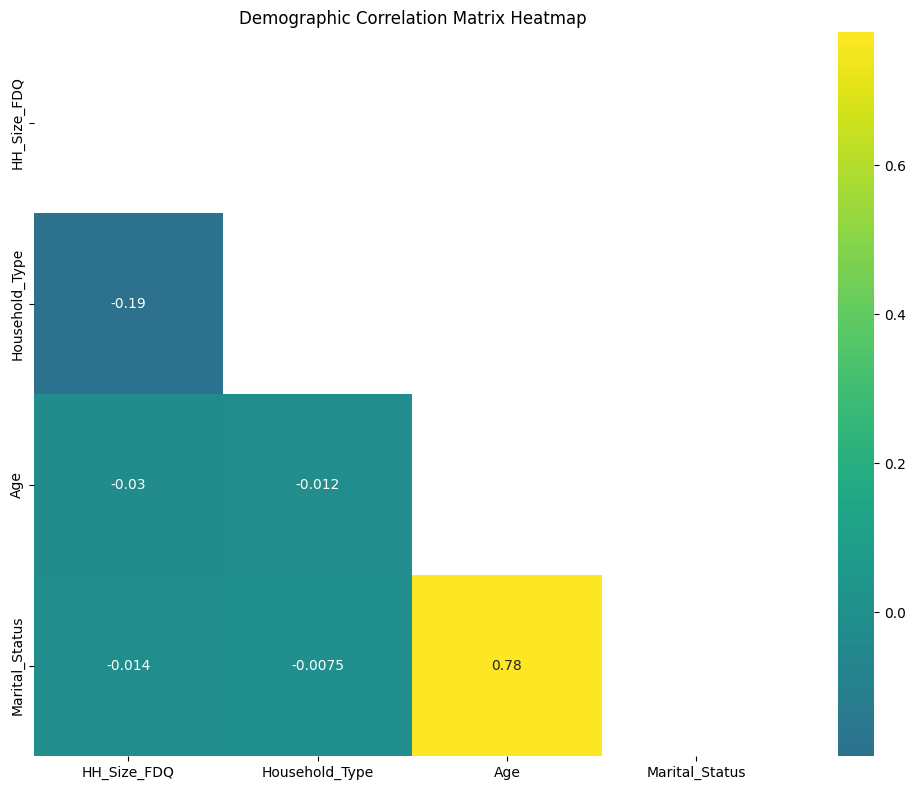

In [9]:
merge_plot_heatmap(
    levels=[2, 3],
    cols=demographic_cols__02_03,
    title="Demographic"
)

# Income Stability

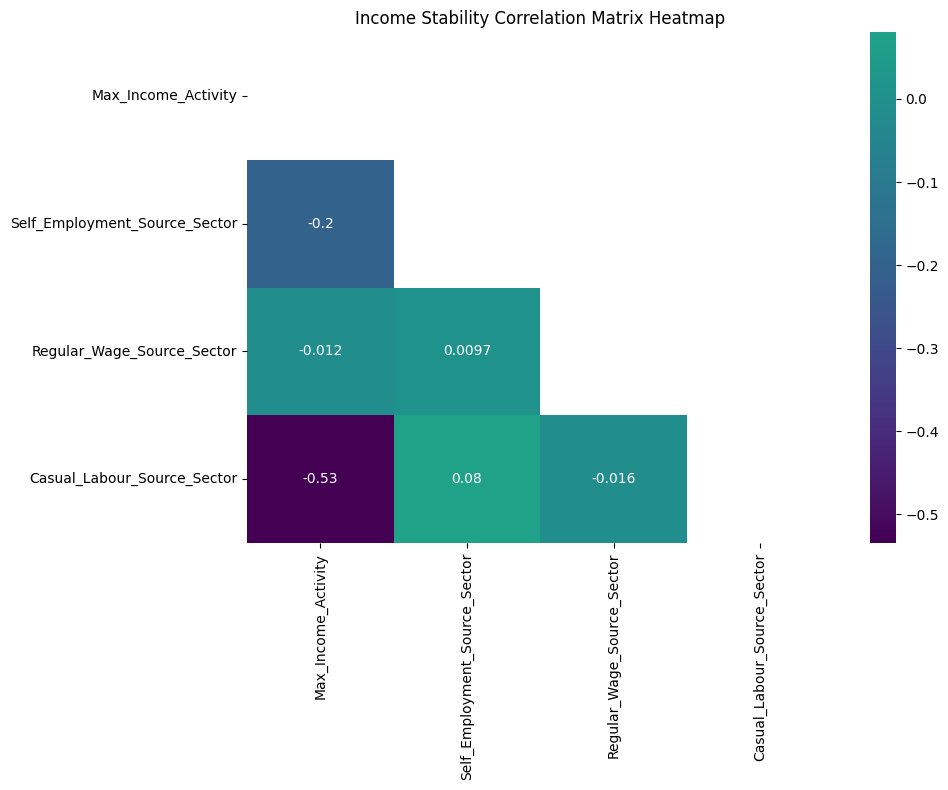

In [10]:
merge_plot_heatmap(
    levels=[3],
    cols=income_stability_cols_03,
    title="Income Stability"
)

# No of Assets

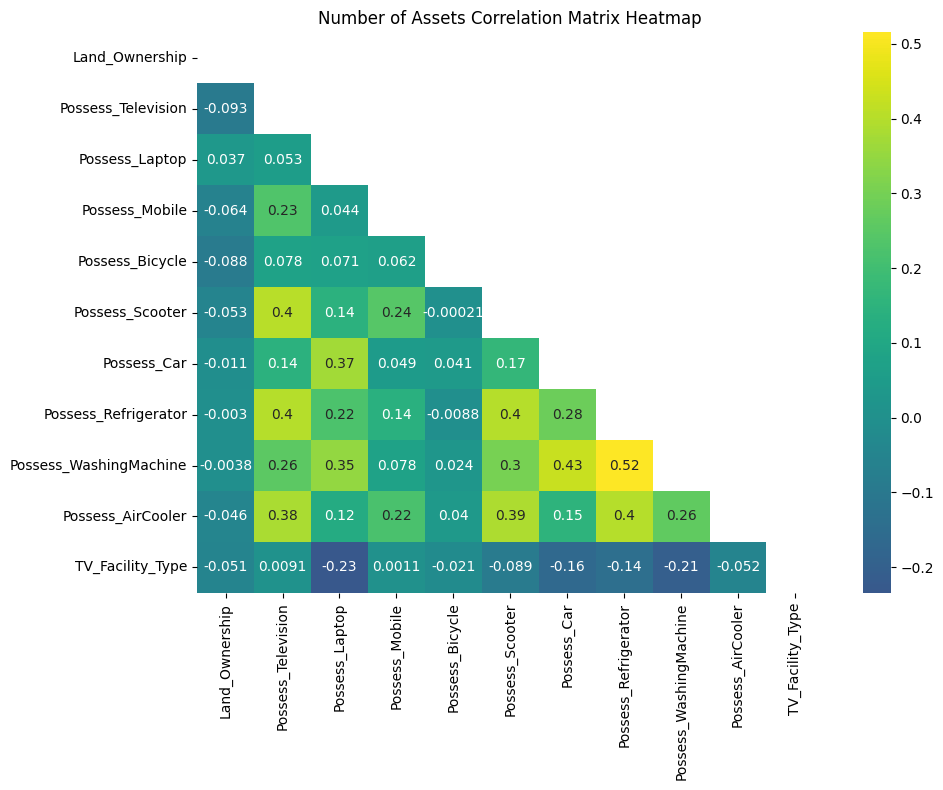

In [11]:
merge_plot_heatmap(
    levels=[3, 11],
    cols=num_assets_cols_03_11,
    title="Number of Assets"
)

# Income

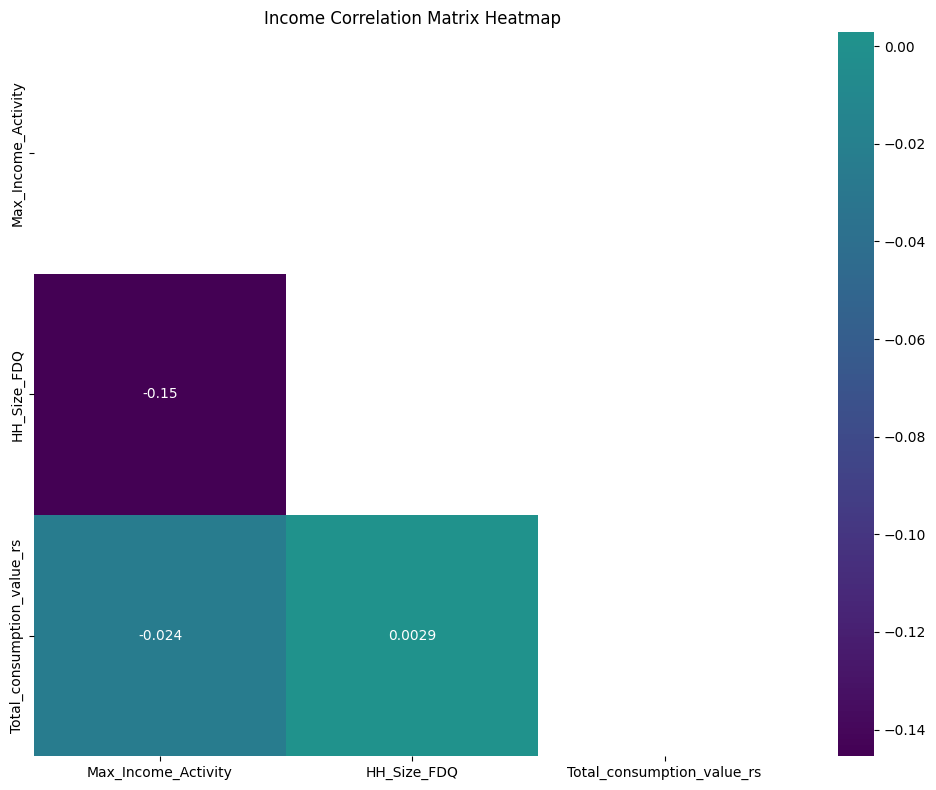

In [15]:
merge_plot_heatmap(
    levels=[3, 8],
    cols=income_cols_03_08,
    title="Income"
)

# Device Access

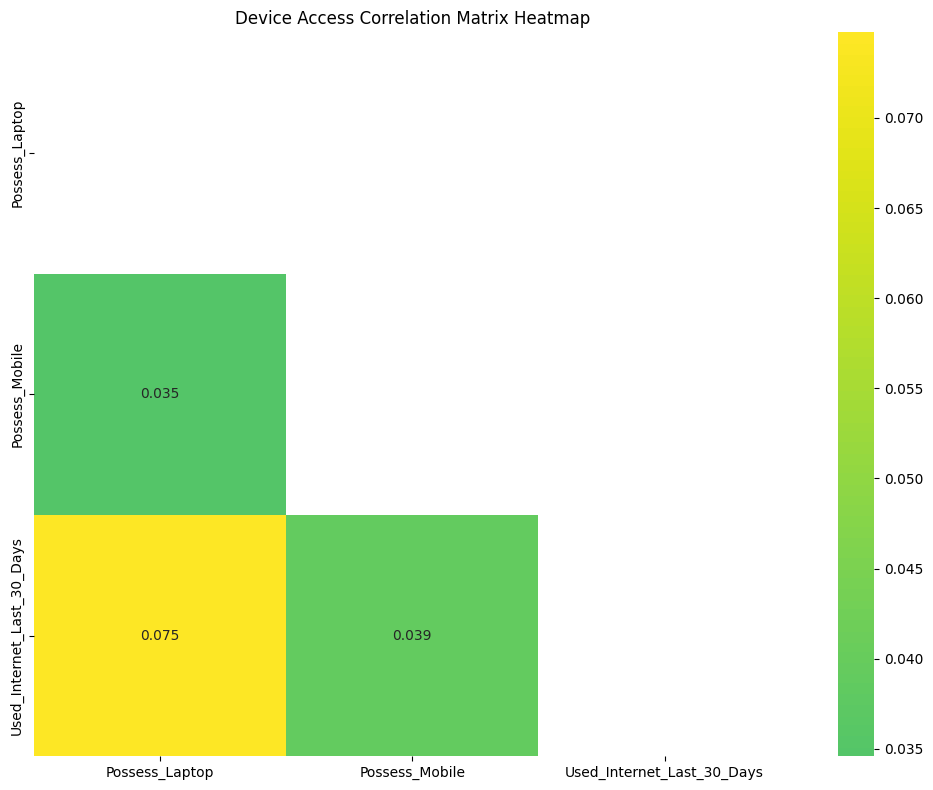

In [ ]:
merge_plot_heatmap(
    levels=[2, 11],
    cols=device_access_cols_02_11,
    title="Device Access"
)

In [3]:
def merge_plot_heatmap(levels: list, cols: list, title: str):
    base_path = r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr"

    dfs = []

    # Load only required columns using lazy scan
    for level in levels:
        file_path = f"{base_path}/cor-{level}.parquet"

        lf = (
            pl.scan_parquet(file_path)
            .select(["FSU_Serial_No"] + cols)  
        )
        
        dfs.append(lf)

    # Merge all lazily
    mdf = dfs[0]
    for lf in dfs[1:]:
        mdf = mdf.join(lf, on="FSU_Serial_No", how="inner")

    # Collect
    mdf = mdf.collect()  

    # Compute correlation only for selected columns
    corr = mdf.select(cols).to_pandas().corr()

    # Mask for upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr,
        annot=True,
        cmap='viridis',
        center=0,
        cbar=True,
        mask=mask,
        xticklabels=corr.columns,
        yticklabels=corr.columns
    )

    plt.title(f"{title} Correlation Matrix Heatmap")
    plt.tight_layout()
    plt.show()

    del mdf
    del corr

# Welfare Usage

In [10]:
welfare_usage_07

['LPG_subsidy_received', 'Free_electricity']

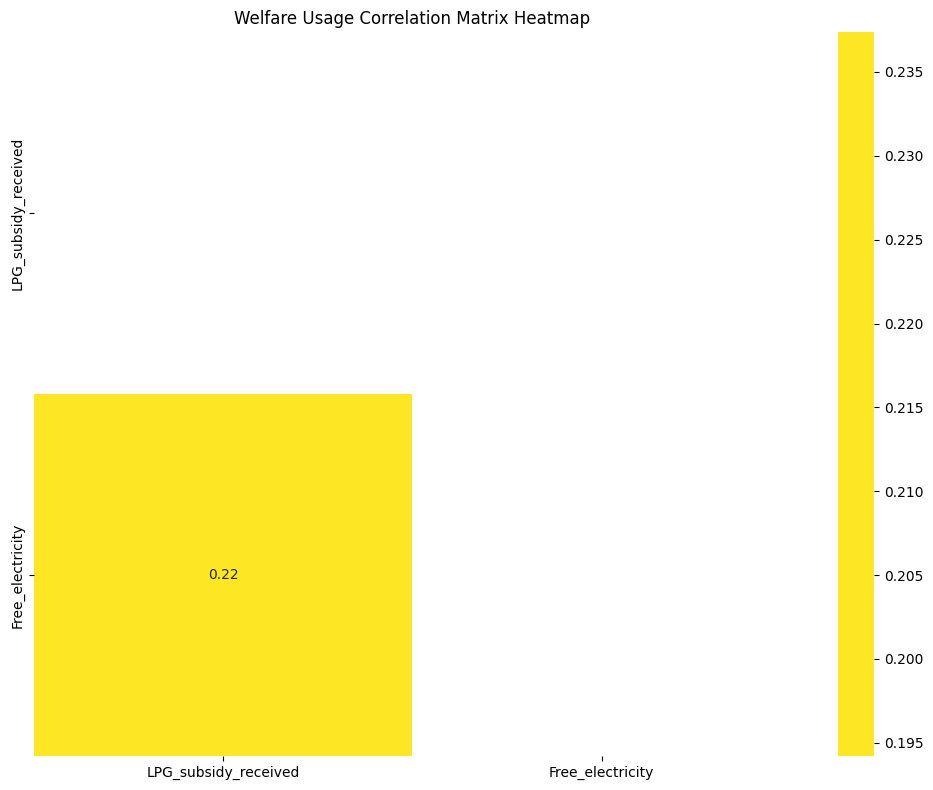

In [9]:
merge_plot_heatmap(
    levels=[7],
    cols=welfare_usage_07,
    title="Welfare Usage"
)

In [9]:
def merge_plot_heatmap(levels: list, cols: list, title: str):
    base_path = r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr"
    dfs = []

    for level in levels:
        file_path = f"{base_path}/cor-{level}.parquet"

        # Read schema only
        schema_cols = pl.scan_parquet(file_path).schema.keys()

        # Keep only columns that actually exist
        valid_cols = ["FSU_Serial_No"] + [c for c in cols if c in schema_cols]

        lf = pl.scan_parquet(file_path).select(valid_cols)

        dfs.append(lf)

    # Merge
    mdf = dfs[0]
    for lf in dfs[1:]:
        mdf = mdf.join(lf, on="FSU_Serial_No", how="inner")

    # Collect
    mdf = mdf.collect()

    # Only use columns that ended up in merged DF
    final_cols = [c for c in cols if c in mdf.columns]

    # Compute correlation
    corr = mdf.select(final_cols).corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap="viridis", mask=mask)
    plt.title(f"{title} Correlation Matrix")
    plt.show()


# Online Activity

In [21]:
online_activity_cols_04_07_15 = [
    'Online_purchase_fuel_light',
 'Online_purchase_toilet_articles',
 'Online_purchase_education',
 'Online_purchase_medicine',
 'Online_purchase_services',
 'Online_Groceries',
 'Online_Milk',
 'Online_Vegetables',
 'Online_Fresh_Fruits',
 'Online_Dry_Fruits',
 'Online_Egg_Fish_Meat',
 'Online_Served_Processed_Food',
 'Online_Packed_Processed_Food',
 'Online_Other_Food_Items',
 'ONLINE_EXPENDITURE']

C:\Users\Rudra\AppData\Local\Temp\ipykernel_24252\2088354185.py:9: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  schema_cols = pl.scan_parquet(file_path).schema.keys()


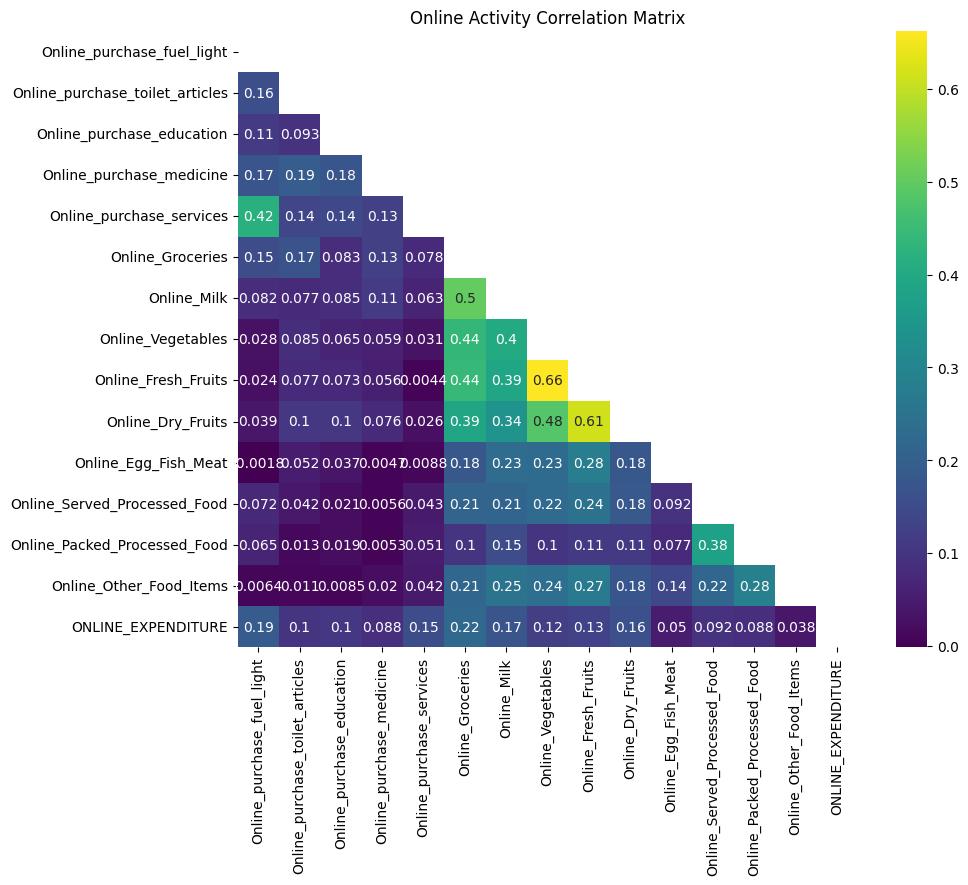

: 

In [ ]:
merge_plot_heatmap(
    levels=[4, 7, 15],
    cols=online_activity_cols_04_07_15 ,
    title="Online Activity"
)

# Professional Field

In [7]:
merge_plot_heatmap(
    levels=[2, 3, 4, 7],
    cols=professional_field_cols_02_03_04_07,
    title="Professional Field"
)

NameError: name 'professional_field_cols_02_03_04_07' is not defined

In [11]:
merge_plot_heatmap(
    levels=[2, 3, 4, 7],
    cols=professional_field_cols_02_03_04_07,
    title="Professional Field"
)

C:\Users\Rudra\AppData\Local\Temp\ipykernel_1264\2593093259.py:9: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  schema_cols = pl.scan_parquet(file_path).schema.keys()


: 

In [9]:
professional_field_cols_02_03_04_07

['Used_Internet_Last_30_Days',
 'Ration_Card_Type',
 'Benefitted_From_PMGKY',
 'Ration_Rice',
 'Ration_Wheat',
 'Ration_Coarse_Grain',
 'Ration_Sugar',
 'Ration_Pulses',
 'Ration_Edible_Oil',
 'Ration_Other_Food_Items']

In [4]:
professional_field_cols_03_04 = [
 'Ration_Card_Type',
 'Benefitted_From_PMGKY',
 'Ration_Rice',
 'Ration_Wheat',
 'Ration_Coarse_Grain',
 'Ration_Sugar',
 'Ration_Pulses',
 'Ration_Edible_Oil',
 'Ration_Other_Food_Items']

- First function code it work

C:\Users\Rudra\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Rudra\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


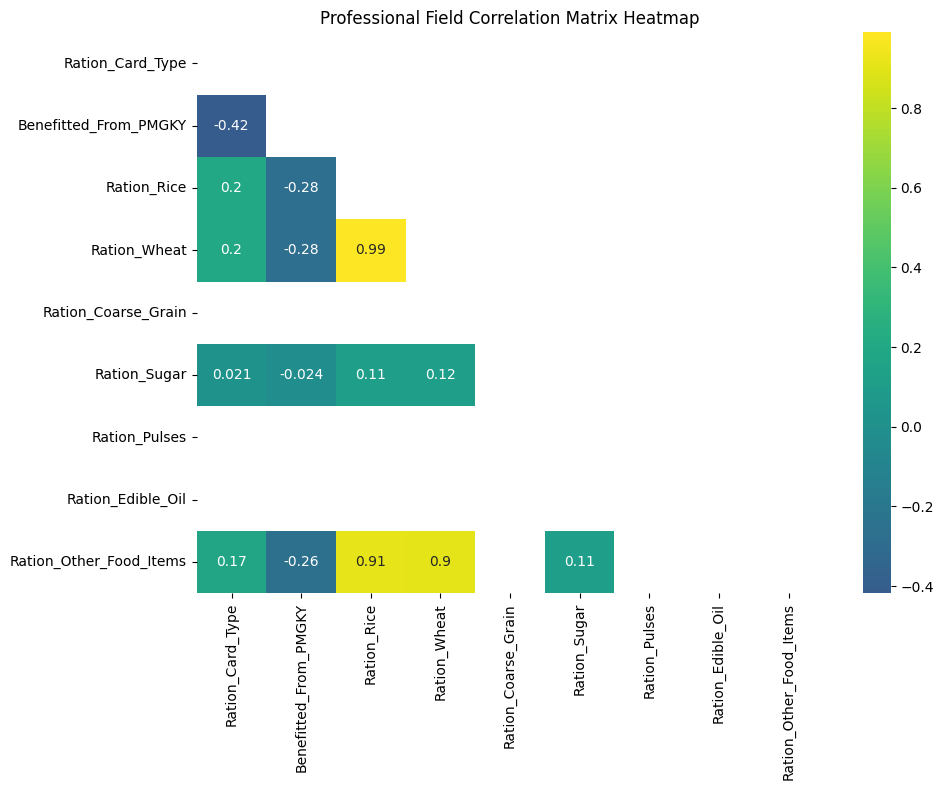

In [12]:
merge_plot_heatmap(
    levels=[3, 4,],
    cols=professional_field_cols_03_04,
    title="Professional Field"
)

# Direct & Indirect Welfare

C:\Users\Rudra\AppData\Local\Temp\ipykernel_1264\2088354185.py:9: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  schema_cols = pl.scan_parquet(file_path).schema.keys()


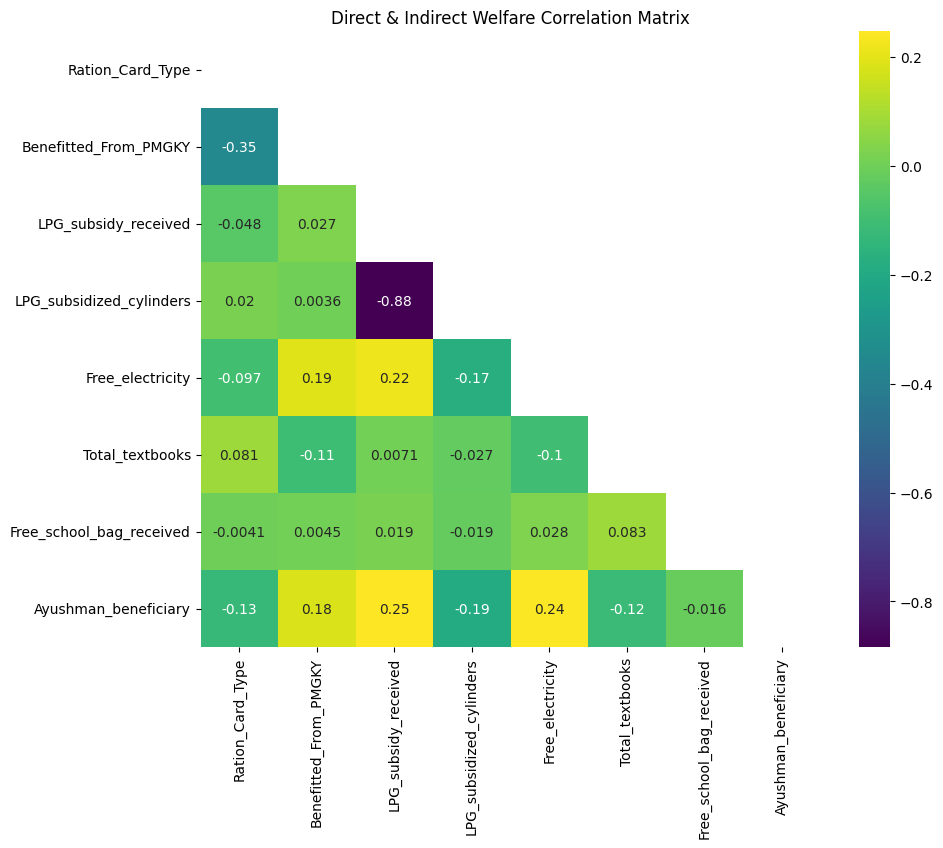

In [8]:
merge_plot_heatmap(
    levels=[3, 7],
    cols=direct_indirect_welfare_usage_03_07,
    title="Direct & Indirect Welfare"
)

# Error

```py
The Kernel crashed while executing code in the current cell or a previous cell. 
Please review the code in the cell(s) to identify a possible cause of the failure. 
Click <a href='https://aka.ms/vscodeJupyterKernelCrash'>here</a> for more info. 
View Jupyter <a href='command:jupyter.viewOutput'>log</a> for further details.
```

```py
---------------------------------------------------------------------------
MemoryError                               Traceback (most recent call last)
Cell In[17], line 1
----> 1 merge_plot_heatmap(
      2     levels=[4, 7, 15],
      3     cols=online_activity_cols_04_07_15 ,
      4     title="Online Activity"
      5 )

Cell In[8], line 41, in merge_plot_heatmap(levels, cols, title)
     38 mdf = mdf.select(cols)
     40 # Compute the correlation matrix
---> 41 corr = mdf.corr()
     43 # Mask for the upper triangle 
     44 mask = np.triu(np.ones_like(corr, dtype=bool))

File ~\AppData\Roaming\Python\Python311\site-packages\polars\dataframe\frame.py:11830, in DataFrame.corr(self, **kwargs)
  11799 def corr(self, **kwargs: Any) -> DataFrame:
  11800     """
  11801     Return pairwise Pearson product-moment correlation coefficients between columns.
  11802 
   (...)  11828     └──────┴──────┴──────┘
  11829     """
> 11830     correlation_matrix = np.corrcoef(self.to_numpy(), rowvar=False, **kwargs)
  11831     if self.width == 1:
  11832         correlation_matrix = np.array([correlation_matrix])

File ~\AppData\Roaming\Python\Python311\site-packages\polars\dataframe\frame.py:2020, in DataFrame.to_numpy(self, order, writable, allow_copy, structured, use_pyarrow)
   2017         out[c] = arrays[idx]
   2018     return out
-> 2020 return self._df.to_numpy(order, writable=writable, allow_copy=allow_copy)

File ~\AppData\Roaming\Python\Python311\site-packages\numpy\_core\shape_base.py:291, in vstack(tup, dtype, casting)
    289 if not isinstance(arrs, tuple):
    290     arrs = (arrs,)
--> 291 return _nx.concatenate(arrs, 0, dtype=dtype, casting=casting)

MemoryError: Unable to allocate 9.71 GiB for an array with shape (15, 86868432) and data type float64
```